In [1]:
import importlib
import scraper as sc
importlib.reload(sc)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import ssl
import pandas as pd
import os

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download('punkt')

plt.style.use('ggplot')

[nltk_data] Downloading package punkt to /Users/kaush/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
nsdq = sc.nsdq_tickers("nasdaq.csv")
posts_df = sc.fetch_submissions("wallstreetbets", 100)
posts_df = sc.post_extract_tickers(posts_df, nsdq)
posts_df.head(50)

,subreddit,submission_id,author,created_utc,title,body,url,selftext,score,num_comments,is_self,upvote_ratio,permalink,content,p_mentioned
0,wallstreetbets,1nkoh64,Conscious-Quarter423,1758240003,"$10,000 of Intel bought 25 years ago is worth ...",,https://i.redd.it/fbhz9kh8i0qf1.jpeg,,43521,890,False,0.96,https://www.reddit.com/r/wallstreetbets/commen...,"$10,000 of Intel bought 25 years ago is worth ...",[]
1,wallstreetbets,1nl2uib,dlee4,1758286634,SEC to propose rule change on Trump's call to ...,,https://www.cnbc.com/2025/09/19/sec-to-propose...,,2950,388,False,0.96,https://www.reddit.com/r/wallstreetbets/commen...,SEC to propose rule change on Trump's call to ...,[]
2,wallstreetbets,1nl33rf,37366034,1758287274,"Not really sure how futures work, but I shorte...",Anyone know how these work? I might start doin...,https://www.reddit.com/gallery/1nl33rf,Anyone know how these work? I might start doin...,1352,315,False,0.97,https://www.reddit.com/r/wallstreetbets/commen...,"Not really sure how futures work, but I shorte...",[]
3,wallstreetbets,1nkok23,zjz,1758240214,If you got a DM it is a scam! Reddit is stupid...,I'm trying to get admins to take down that sub...,https://www.reddit.com/r/wallstreetbets/commen...,I'm trying to get admins to take down that sub...,1009,275,True,0.97,https://www.reddit.com/r/wallstreetbets/commen...,If you got a DM it is a scam! Reddit is stupid...,[]
4,wallstreetbets,1nkrobw,Alert-Growth-8326,1758249018,Were these Intel calls sold a day too early?,,https://i.redd.it/uhlxivtx81qf1.jpeg,,862,170,False,0.97,https://www.reddit.com/r/wallstreetbets/commen...,Were these Intel calls sold a day too early?,[]
5,wallstreetbets,1nkow7c,RedditUsername71,1758241177,[GAP]PING UP,"Alright, listen up you degenerates - while eve...",https://www.reddit.com/r/wallstreetbets/commen...,"Alright, listen up you degenerates - while eve...",310,242,True,0.94,https://www.reddit.com/r/wallstreetbets/commen...,"[GAP]PING UP Alright, listen up you degenerate...","[AI, SG, AN, ARE, NOW, AEO, NOTE, WAY, UP, ALL..."
6,wallstreetbets,1nkqs0i,y2j514,1758246496,Phishy phishy BEWARE,Just got a mod mail telling me to pair my acco...,https://i.redd.it/twhvd3oj11qf1.jpeg,Just got a mod mail telling me to pair my acco...,261,41,False,0.95,https://www.reddit.com/r/wallstreetbets/commen...,Phishy phishy BEWARE Just got a mod mail telli...,[]
7,wallstreetbets,1nl9xil,Direct_Plantain_95,1758303067,"UUUU blessed, on way to $20",,https://i.redd.it/lqgujkerp5qf1.jpeg,,251,71,False,0.97,https://www.reddit.com/r/wallstreetbets/commen...,"UUUU blessed, on way to $20",[UUUU]
8,wallstreetbets,1nl8l2t,acoddo,1758300023,I think I’m gonna get the new iPhone,,https://i.redd.it/xg5zps8pg5qf1.jpeg,,243,19,False,0.97,https://www.reddit.com/r/wallstreetbets/commen...,I think I’m gonna get the new iPhone,[]
9,wallstreetbets,1nkkxu5,everybodydumb,1758230883,50k YOLO Opendoor Open,Warm regards,https://i.redd.it/7eihsm94rzpf1.png,Warm regards,215,150,False,0.91,https://www.reddit.com/r/wallstreetbets/commen...,50k YOLO Opendoor Open Warm regards,[]


In [3]:
cmts = sc.fetch_top_comments(posts_df["submission_id"][0])
cmts

,submission id,comment id,author,body,score,permalink,parent
0,1nkoh64,nezdjyj,VisualMod,\n**User Report**| | | |\n:--|:--|:--|:--\n**T...,1,https://www.reddit.com/r/wallstreetbets/commen...,t3_1nkoh64
1,1nkoh64,nezfucr,AaronSpanki,https://preview.redd.it/tc5jxftpk0qf1.png?widt...,4164,https://www.reddit.com/r/wallstreetbets/commen...,t3_1nkoh64
2,1nkoh64,nezg4ng,No_Complex_2603,$10k worth of degenerate 3DTE calls is worth $...,3427,https://www.reddit.com/r/wallstreetbets/commen...,t3_1nkoh64
3,1nkoh64,nezgobq,AttorneyExisting1651,That is a better ROI than most regards on this...,850,https://www.reddit.com/r/wallstreetbets/commen...,t3_1nkoh64
4,1nkoh64,neze6pz,idisagreeurwrong,"$10,000 of Intel bought 25 days ago is worth $...",3030,https://www.reddit.com/r/wallstreetbets/commen...,t3_1nkoh64
...,...,...,...,...,...,...,...
296,1nkoh64,nf0uocs,perspectiveiskey,25 year gravestone doji.,1,https://www.reddit.com/r/wallstreetbets/commen...,t3_1nkoh64
297,1nkoh64,nf0uz8n,GoobeNanmaga,Joke is on you! I bought it at $55,1,https://www.reddit.com/r/wallstreetbets/commen...,t3_1nkoh64
298,1nkoh64,nf0v8lt,900YearsHODL-IHave,Ah a Stablestock!,1,https://www.reddit.com/r/wallstreetbets/commen...,t3_1nkoh64
299,1nkoh64,nf0w6xy,USAhotdogteam,Lmfao,1,https://www.reddit.com/r/wallstreetbets/commen...,t3_1nkoh64


In [4]:
sample = posts_df["content"][1]
tokens = nltk.word_tokenize(sample)
tagged = nltk.pos_tag(tokens)
entities = nltk.chunk.ne_chunk(tagged)

In [5]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm import tqdm

sia = SentimentIntensityAnalyzer()

In [6]:
sia.polarity_scores(sample)

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

In [7]:
res = {}
for i, row in tqdm(posts_df.iterrows(), total = len(posts_df)):
    text = row["content"]
    sub_id = row["submission_id"]
    
    res[sub_id] = sia.polarity_scores(text)

100%|██████████| 57/57 [00:00<00:00, 846.18it/s]


In [8]:
vaders = pd.DataFrame(res).T
vaders = vaders.reset_index().rename(columns={'index':'submission_id'})
vaders = vaders.merge(posts_df, how='left')
vaders.head(10)

,submission_id,neg,neu,pos,compound,subreddit,author,created_utc,title,body,url,selftext,score,num_comments,is_self,upvote_ratio,permalink,content,p_mentioned
0,1nkoh64,0.000,0.840,0.160,0.2263,wallstreetbets,Conscious-Quarter423,1758240003,"$10,000 of Intel bought 25 years ago is worth ...",,https://i.redd.it/fbhz9kh8i0qf1.jpeg,,43521,890,False,0.96,https://www.reddit.com/r/wallstreetbets/commen...,"$10,000 of Intel bought 25 years ago is worth ...",[]
1,1nl2uib,0.000,1.000,0.000,0.0000,wallstreetbets,dlee4,1758286634,SEC to propose rule change on Trump's call to ...,,https://www.cnbc.com/2025/09/19/sec-to-propose...,,2950,388,False,0.96,https://www.reddit.com/r/wallstreetbets/commen...,SEC to propose rule change on Trump's call to ...,[]
2,1nl33rf,0.032,0.903,0.065,0.3941,wallstreetbets,37366034,1758287274,"Not really sure how futures work, but I shorte...",Anyone know how these work? I might start doin...,https://www.reddit.com/gallery/1nl33rf,Anyone know how these work? I might start doin...,1352,315,False,0.97,https://www.reddit.com/r/wallstreetbets/commen...,"Not really sure how futures work, but I shorte...",[]
3,1nkok23,0.092,0.908,0.000,-0.8123,wallstreetbets,zjz,1758240214,If you got a DM it is a scam! Reddit is stupid...,I'm trying to get admins to take down that sub...,https://www.reddit.com/r/wallstreetbets/commen...,I'm trying to get admins to take down that sub...,1009,275,True,0.97,https://www.reddit.com/r/wallstreetbets/commen...,If you got a DM it is a scam! Reddit is stupid...,[]
4,1nkrobw,0.000,1.000,0.000,0.0000,wallstreetbets,Alert-Growth-8326,1758249018,Were these Intel calls sold a day too early?,,https://i.redd.it/uhlxivtx81qf1.jpeg,,862,170,False,0.97,https://www.reddit.com/r/wallstreetbets/commen...,Were these Intel calls sold a day too early?,[]
5,1nkow7c,0.032,0.845,0.122,0.9998,wallstreetbets,RedditUsername71,1758241177,[GAP]PING UP,"Alright, listen up you degenerates - while eve...",https://www.reddit.com/r/wallstreetbets/commen...,"Alright, listen up you degenerates - while eve...",310,242,True,0.94,https://www.reddit.com/r/wallstreetbets/commen...,"[GAP]PING UP Alright, listen up you degenerate...","[AI, SG, AN, ARE, NOW, AEO, NOTE, WAY, UP, ALL..."
6,1nkqs0i,0.000,0.905,0.095,0.7579,wallstreetbets,y2j514,1758246496,Phishy phishy BEWARE,Just got a mod mail telling me to pair my acco...,https://i.redd.it/twhvd3oj11qf1.jpeg,Just got a mod mail telling me to pair my acco...,261,41,False,0.95,https://www.reddit.com/r/wallstreetbets/commen...,Phishy phishy BEWARE Just got a mod mail telli...,[]
7,1nl9xil,0.000,0.562,0.438,0.5994,wallstreetbets,Direct_Plantain_95,1758303067,"UUUU blessed, on way to $20",,https://i.redd.it/lqgujkerp5qf1.jpeg,,251,71,False,0.97,https://www.reddit.com/r/wallstreetbets/commen...,"UUUU blessed, on way to $20",[UUUU]
8,1nl8l2t,0.000,1.000,0.000,0.0000,wallstreetbets,acoddo,1758300023,I think I’m gonna get the new iPhone,,https://i.redd.it/xg5zps8pg5qf1.jpeg,,243,19,False,0.97,https://www.reddit.com/r/wallstreetbets/commen...,I think I’m gonna get the new iPhone,[]
9,1nkkxu5,0.000,0.458,0.542,0.5766,wallstreetbets,everybodydumb,1758230883,50k YOLO Opendoor Open,Warm regards,https://i.redd.it/7eihsm94rzpf1.png,Warm regards,215,150,False,0.91,https://www.reddit.com/r/wallstreetbets/commen...,50k YOLO Opendoor Open Warm regards,[]


In [9]:
cmt_scores = {}
for i, row in tqdm(posts_df.iterrows(), total=len(posts_df)):
    cmts_df = sc.fetch_top_comments(row["submission_id"])
    if cmts_df.empty:
        avg_compound = None
    else:
        cmts_df["compound"] = cmts_df["body"].apply(lambda x: sia.polarity_scores(x)["compound"])
        avg_compound = cmts_df["compound"].mean()
    cmt_scores[row["submission_id"]] = avg_compound

comment_scores_df = pd.DataFrame.from_dict(cmt_scores, orient = 'index', columns = ["c_compound"])
comment_scores_df = comment_scores_df.reset_index().rename(columns = {'index' : 'submission_id'})
merged = vaders.merge(comment_scores_df, on='submission_id', how='right')

100%|██████████| 57/57 [00:37<00:00,  1.53it/s]


In [10]:
merged.head(10)

,submission_id,neg,neu,pos,compound,subreddit,author,created_utc,title,body,url,selftext,score,num_comments,is_self,upvote_ratio,permalink,content,p_mentioned,c_compound
0,1nkoh64,0.000,0.840,0.160,0.2263,wallstreetbets,Conscious-Quarter423,1758240003,"$10,000 of Intel bought 25 years ago is worth ...",,https://i.redd.it/fbhz9kh8i0qf1.jpeg,,43521,890,False,0.96,https://www.reddit.com/r/wallstreetbets/commen...,"$10,000 of Intel bought 25 years ago is worth ...",[],0.137364
1,1nl2uib,0.000,1.000,0.000,0.0000,wallstreetbets,dlee4,1758286634,SEC to propose rule change on Trump's call to ...,,https://www.cnbc.com/2025/09/19/sec-to-propose...,,2950,388,False,0.96,https://www.reddit.com/r/wallstreetbets/commen...,SEC to propose rule change on Trump's call to ...,[],-0.077453
2,1nl33rf,0.032,0.903,0.065,0.3941,wallstreetbets,37366034,1758287274,"Not really sure how futures work, but I shorte...",Anyone know how these work? I might start doin...,https://www.reddit.com/gallery/1nl33rf,Anyone know how these work? I might start doin...,1352,315,False,0.97,https://www.reddit.com/r/wallstreetbets/commen...,"Not really sure how futures work, but I shorte...",[],0.162398
3,1nkok23,0.092,0.908,0.000,-0.8123,wallstreetbets,zjz,1758240214,If you got a DM it is a scam! Reddit is stupid...,I'm trying to get admins to take down that sub...,https://www.reddit.com/r/wallstreetbets/commen...,I'm trying to get admins to take down that sub...,1009,275,True,0.97,https://www.reddit.com/r/wallstreetbets/commen...,If you got a DM it is a scam! Reddit is stupid...,[],-0.046270
4,1nkrobw,0.000,1.000,0.000,0.0000,wallstreetbets,Alert-Growth-8326,1758249018,Were these Intel calls sold a day too early?,,https://i.redd.it/uhlxivtx81qf1.jpeg,,862,170,False,0.97,https://www.reddit.com/r/wallstreetbets/commen...,Were these Intel calls sold a day too early?,[],0.043128
5,1nkow7c,0.032,0.845,0.122,0.9998,wallstreetbets,RedditUsername71,1758241177,[GAP]PING UP,"Alright, listen up you degenerates - while eve...",https://www.reddit.com/r/wallstreetbets/commen...,"Alright, listen up you degenerates - while eve...",310,242,True,0.94,https://www.reddit.com/r/wallstreetbets/commen...,"[GAP]PING UP Alright, listen up you degenerate...","[AI, SG, AN, ARE, NOW, AEO, NOTE, WAY, UP, ALL...",0.175119
6,1nkqs0i,0.000,0.905,0.095,0.7579,wallstreetbets,y2j514,1758246496,Phishy phishy BEWARE,Just got a mod mail telling me to pair my acco...,https://i.redd.it/twhvd3oj11qf1.jpeg,Just got a mod mail telling me to pair my acco...,261,41,False,0.95,https://www.reddit.com/r/wallstreetbets/commen...,Phishy phishy BEWARE Just got a mod mail telli...,[],-0.061835
7,1nl9xil,0.000,0.562,0.438,0.5994,wallstreetbets,Direct_Plantain_95,1758303067,"UUUU blessed, on way to $20",,https://i.redd.it/lqgujkerp5qf1.jpeg,,251,71,False,0.97,https://www.reddit.com/r/wallstreetbets/commen...,"UUUU blessed, on way to $20",[UUUU],0.128396
8,1nl8l2t,0.000,1.000,0.000,0.0000,wallstreetbets,acoddo,1758300023,I think I’m gonna get the new iPhone,,https://i.redd.it/xg5zps8pg5qf1.jpeg,,243,19,False,0.97,https://www.reddit.com/r/wallstreetbets/commen...,I think I’m gonna get the new iPhone,[],0.195064
9,1nkkxu5,0.000,0.458,0.542,0.5766,wallstreetbets,everybodydumb,1758230883,50k YOLO Opendoor Open,Warm regards,https://i.redd.it/7eihsm94rzpf1.png,Warm regards,215,150,False,0.91,https://www.reddit.com/r/wallstreetbets/commen...,50k YOLO Opendoor Open Warm regards,[],0.103762


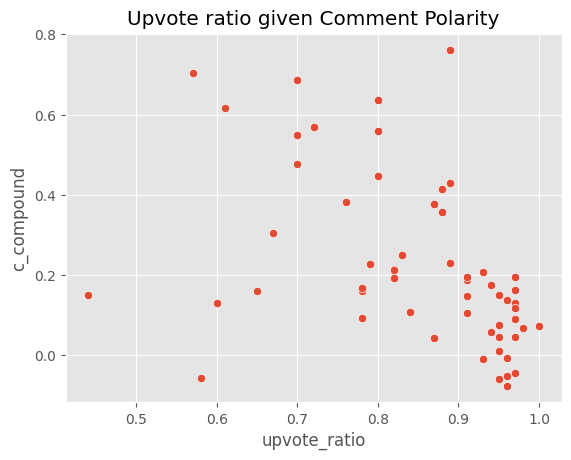

In [11]:
axis = sns.scatterplot(data = merged, x = 'upvote_ratio', y = 'c_compound')
axis.set_title("Upvote ratio given Comment Polarity")
plt.show()

In [12]:
from huggingface_hub import InferenceClient
from dotenv import load_dotenv

load_dotenv("/Users/kaush/Documents/Hotstox/credentials.env")
hf_token = os.getenv("HF_TOKEN")

client = InferenceClient(api_key = hf_token)

result = client.text_classification(merged["content"][0], model="ProsusAI/finbert")

print(result)



/Users/kaush/Library/Python/3.12/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[TextClassificationOutputElement(label='neutral', score=0.933682382106781), TextClassificationOutputElement(label='positive', score=0.05211307853460312), TextClassificationOutputElement(label='negative', score=0.01420451607555151)]


In [17]:
from transformers import pipeline
clf = pipeline("text-classification", model="ProsusAI/finbert")
i = 6
print(merged["content"][i])
print(merged["p_mentioned"][i])
clf(merged["content"][i], truncation=True)

Device set to use mps:0


Phishy phishy BEWARE Just got a mod mail telling me to pair my account with Coinbase. It seems to have come from the official mod account but if it smells like your moms vagina, and looks like your moms vagina - it’s probably fish. 

I followed the link for curiosity and it brings you to a google powered site that asks you for your wallets recovery code. 

BEWARE 

[]


[{'label': 'neutral', 'score': 0.9270239472389221}]